# Optimierte Spin-Echo-Sequenz

Dieses Notebook erstellt eine Pulseq-Sequenzdatei für eine Spin-Echo-Sequenz unter Verwendung von zwei optimierten RF-Pulsen (90° und 180°).
Die optimierten Pulse werden aus den Ergebnissen der `SE_optimization.ipynb` geladen und mit der `make_arbitrary_rf`-Funktion von pypulseq in eine Sequenz integriert.

Der grundlegende Ablauf ist:
1. Laden der optimierten Pulse (90° und 180°) aus dem gespeicherten Checkpoint der SE-Optimierung.
2. Visualisieren und Exportieren der optimierten Pulse.
3. Erstellen einer Spin-Echo-Sequenzdatei ähnlich zu `SE_seq.ipynb`, aber mit den optimierten Pulsen.

In [1]:
from pathlib import Path
import torch
import numpy as np
import matplotlib.pyplot as plt
import json
import pypulseq as pp

# Erweiterte Imports für die Verwendung von make_arbitrary_rf
from bmc.utils.seq.write import write_seq

## 1. Laden der optimierten Pulse aus dem Checkpoint

Zunächst müssen wir die beiden optimierten Pulse (90° und 180°) aus dem gespeicherten Checkpoint der SE-Optimierung laden.

In [2]:
# Pfad zum besten Checkpoint der SE-Optimierung
wdir = Path().resolve().parent
# Korrigierter Pfad zum Checkpoint-Verzeichnis der SE-Optimierung
checkpoint_dir = wdir / "bmc" / "optimize" / "gauss_optimization" / "checkpoints" / "SE_optimization_163_8"
checkpoint_path = checkpoint_dir / "best_checkpoint.pt"

# Überprüfen, ob der Checkpoint existiert
if not checkpoint_path.exists():
    raise FileNotFoundError(f"Checkpoint-Datei {checkpoint_path} wurde nicht gefunden.")

# Laden des Checkpoints
# Lade auf CPU, falls auf GPU trainiert wurde und hier keine GPU verfügbar ist
checkpoint = torch.load(checkpoint_path, map_location=torch.device('cpu'))
print(f"Checkpoint von Epoche {checkpoint.get('epoch', 'unbekannt')} geladen")
print("Typ des Checkpoints:", type(checkpoint))

# Definition der standardmäßigen Pulsdauer - wird später zur Berechnung von dt verwendet
t_pulse = 2e-3  # Standardmäßige Pulsdauer: 2ms

# Versuche, dt aus dem Checkpoint zu laden - nur zur Information, wird nicht direkt verwendet
stored_pulse_dt = None
if 'parameters' in checkpoint and 'dt' in checkpoint['parameters']:
    stored_pulse_dt = float(checkpoint['parameters']['dt'])
    print(f"Aus Checkpoint geladene Abtastzeit (dt): {stored_pulse_dt:.2e} s (wird nur zur Information angezeigt)")
else:
    # Fallback: Versuche dt aus Metadaten zu laden (nur zur Information)
    metadata_path = checkpoint_dir / 'SE_training_metadata.json'
    if metadata_path.exists():
        try:
            with open(metadata_path, 'r') as f:
                metadata = json.load(f)
            if 'dt' in metadata:
                stored_pulse_dt = float(metadata['dt'])
                print(f"Aus Metadaten geladene Abtastzeit (dt): {stored_pulse_dt:.2e} s (wird nur zur Information angezeigt)")
        except Exception as e:
            print(f"Konnte Metadaten nicht laden: {e}")

optimized_pulse_array_90 = None
optimized_pulse_array_180 = None
phase_offset_90 = 0 # Standard-Phasenoffset für 90° Puls
phase_offset_180 = 0 # Standard-Phasenoffset für 180° Puls (relativ zu 90°)

if 'rf_parameters' in checkpoint:
    rf_params = checkpoint['rf_parameters']
    print(f"RF-Parameter gefunden. Anzahl der Pulse: {len(rf_params)}")

    if isinstance(rf_params, list) and len(rf_params) >= 2:
        # Erster Puls (90°)
        pulse_90_data = rf_params[0]
        if isinstance(pulse_90_data, list) and len(pulse_90_data) >= 2:
            amp_90 = pulse_90_data[0]
            phase_90 = pulse_90_data[1] # Phase wird hier geladen, aber pypulseq braucht skalaren Offset
            if isinstance(amp_90, torch.Tensor):
                optimized_pulse_array_90 = amp_90.detach().cpu().numpy()
                print(f"Optimierter 90°-Puls erfolgreich geladen. Form: {optimized_pulse_array_90.shape}")
                # Optional: Phasenoffset aus dem Mittelwert des Phasentensors (experimentell)
                # phase_offset_90 = phase_90.mean().item()
            else:
                print(f"Unerwarteter Typ für 90°-Amplitude: {type(amp_90)}")
        else:
            print(f"Unerwartete Struktur für den ersten Puls: {type(pulse_90_data)}")

        # Zweiter Puls (180°)
        pulse_180_data = rf_params[1]
        if isinstance(pulse_180_data, list) and len(pulse_180_data) >= 2:
            amp_180 = pulse_180_data[0]
            phase_180 = pulse_180_data[1] # Phase wird hier geladen
            if isinstance(amp_180, torch.Tensor):
                optimized_pulse_array_180 = amp_180.detach().cpu().numpy()
                print(f"Optimierter 180°-Puls erfolgreich geladen. Form: {optimized_pulse_array_180.shape}")
                # Optional: Phasenoffset aus dem Mittelwert des Phasentensors (experimentell)
                # phase_offset_180 = phase_180.mean().item()
            else:
                print(f"Unerwarteter Typ für 180°-Amplitude: {type(amp_180)}")
        else:
            print(f"Unerwartete Struktur für den zweiten Puls: {type(pulse_180_data)}")

        # Überprüfen, ob beide Pulse geladen wurden
        if optimized_pulse_array_90 is None or optimized_pulse_array_180 is None:
            raise ValueError("Konnte nicht beide optimierten Pulse aus dem Checkpoint laden.")
        if len(optimized_pulse_array_90) != len(optimized_pulse_array_180):
             print(f"WARNUNG: Die optimierten Pulse haben unterschiedliche Längen ({len(optimized_pulse_array_90)} vs {len(optimized_pulse_array_180)} Samples).")
             # Hier könnte man entscheiden, wie man damit umgeht (z.B. Fehler werfen, anpassen)
                
        # WICHTIG: Berechne die Abtastzeit (dt) basierend auf der Pulsdauer und der Anzahl der Samples
        pulse_dt_90 = t_pulse / len(optimized_pulse_array_90)
        pulse_dt_180 = t_pulse / len(optimized_pulse_array_180)
        
        print(f"Berechnete Abtastzeit für 90°-Puls: {pulse_dt_90:.3e} s (basierend auf {len(optimized_pulse_array_90)} Samples und Pulsdauer {t_pulse*1000} ms)")
        print(f"Berechnete Abtastzeit für 180°-Puls: {pulse_dt_180:.3e} s (basierend auf {len(optimized_pulse_array_180)} Samples und Pulsdauer {t_pulse*1000} ms)")
        
        if stored_pulse_dt is not None:
            print(f"Hinweis: Die berechnete Abtastzeit weicht möglicherweise von der gespeicherten Abtastzeit ({stored_pulse_dt:.3e} s) ab.")

    else:
        raise ValueError(f"Unerwartete Struktur oder Anzahl von Pulsen in rf_parameters: {len(rf_params)}")
else:
    raise ValueError("'rf_parameters' nicht im Checkpoint gefunden.")

Checkpoint von Epoche 299 geladen
Typ des Checkpoints: <class 'dict'>
Aus Checkpoint geladene Abtastzeit (dt): 7.00e-06 s (wird nur zur Information angezeigt)
RF-Parameter gefunden. Anzahl der Pulse: 2
Optimierter 90°-Puls erfolgreich geladen. Form: (286,)
Optimierter 180°-Puls erfolgreich geladen. Form: (286,)
Berechnete Abtastzeit für 90°-Puls: 6.993e-06 s (basierend auf 286 Samples und Pulsdauer 2.0 ms)
Berechnete Abtastzeit für 180°-Puls: 6.993e-06 s (basierend auf 286 Samples und Pulsdauer 2.0 ms)
Hinweis: Die berechnete Abtastzeit weicht möglicherweise von der gespeicherten Abtastzeit (7.000e-06 s) ab.


## 2. Visualisieren und Exportieren der optimierten Pulse

Wir visualisieren die optimierten Pulse und exportieren sie dann für die Verwendung mit `make_arbitrary_rf`.

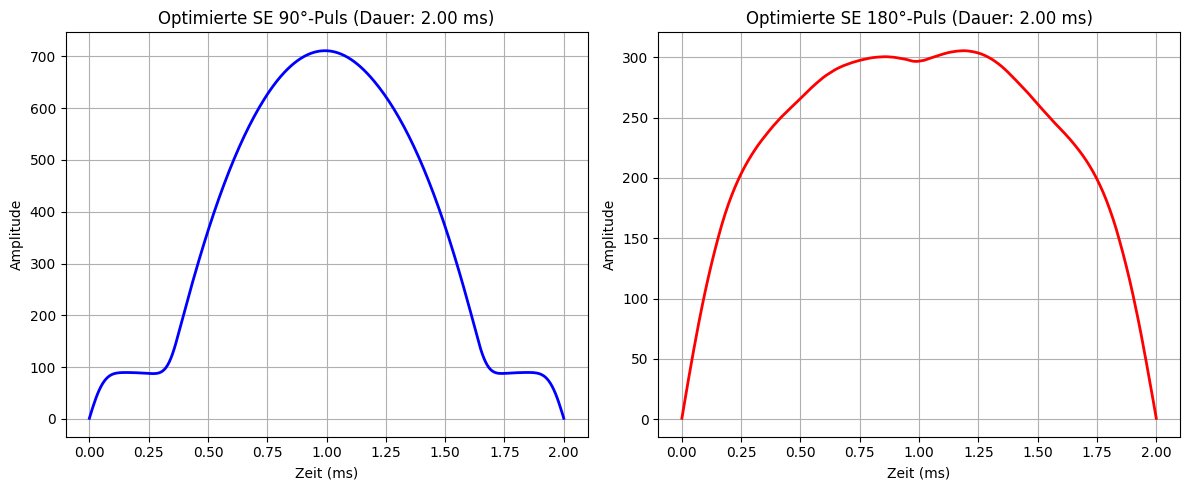

Optimierter 90°-Puls mit dt=6.993006993006993e-06s unter /Users/danielmiksch/JupyterLab/optim/bmc/utils/pulses/optimized_SE_90_pulse.npz gespeichert
Optimierter 180°-Puls mit dt=6.993006993006993e-06s unter /Users/danielmiksch/JupyterLab/optim/bmc/utils/pulses/optimized_SE_180_pulse.npz gespeichert


In [3]:
# Visualisieren der optimierten Pulse
def visualize_SE_pulses(pulse_90, pulse_180, dt_90, dt_180, title_prefix="Optimierte SE"):
    """
    Visualisiert die beiden RF-Pulse (90° und 180°) nebeneinander.

    Args:
        pulse_90: Pulsform (Amplituden) des 90°-Pulses
        pulse_180: Pulsform (Amplituden) des 180°-Pulses
        dt_90: Abtastzeit des 90°-Pulses
        dt_180: Abtastzeit des 180°-Pulses
        title_prefix: Präfix für die Plot-Titel
    """
    num_samples_90 = len(pulse_90)
    num_samples_180 = len(pulse_180)
    t_pulse_90 = num_samples_90 * dt_90
    t_pulse_180 = num_samples_180 * dt_180

    time_axis_90 = np.linspace(0, t_pulse_90 * 1000, num_samples_90)  # Umrechnung in ms
    time_axis_180 = np.linspace(0, t_pulse_180 * 1000, num_samples_180) # Umrechnung in ms

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(time_axis_90, pulse_90, 'b-', linewidth=2)
    plt.title(f"{title_prefix} 90°-Puls (Dauer: {t_pulse_90*1000:.2f} ms)")
    plt.xlabel('Zeit (ms)')
    plt.ylabel('Amplitude')
    plt.grid(True)

    plt.subplot(1, 2, 2)
    plt.plot(time_axis_180, pulse_180, 'r-', linewidth=2)
    plt.title(f"{title_prefix} 180°-Puls (Dauer: {t_pulse_180*1000:.2f} ms)")
    plt.xlabel('Zeit (ms)')
    plt.ylabel('Amplitude')
    plt.grid(True)

    plt.tight_layout()
    plt.show()

# Sicherstellen, dass die Arrays 1D sind
if optimized_pulse_array_90.ndim > 1:
    optimized_pulse_array_90 = optimized_pulse_array_90.flatten()
if optimized_pulse_array_180.ndim > 1:
    optimized_pulse_array_180 = optimized_pulse_array_180.flatten()

# Visualisieren mit den berechneten dt-Werten
visualize_SE_pulses(optimized_pulse_array_90, optimized_pulse_array_180, pulse_dt_90, pulse_dt_180)

# Exportieren der Pulse als NumPy-Arrays für die weitere Verwendung
pulses_dir = wdir / "bmc" / "utils" / "pulses"
pulses_dir.mkdir(exist_ok=True, parents=True)

# Speichern des 90°-Pulses mit dt
pulse_info_90 = {'pulse': optimized_pulse_array_90, 'dt': pulse_dt_90}
pulse_file_path_90 = pulses_dir / "optimized_SE_90_pulse.npz"
np.savez(pulse_file_path_90, **pulse_info_90)
print(f"Optimierter 90°-Puls mit dt={pulse_dt_90}s unter {pulse_file_path_90} gespeichert")

# Speichern des 180°-Pulses mit dt
pulse_info_180 = {'pulse': optimized_pulse_array_180, 'dt': pulse_dt_180}
pulse_file_path_180 = pulses_dir / "optimized_SE_180_pulse.npz"
np.savez(pulse_file_path_180, **pulse_info_180)
print(f"Optimierter 180°-Puls mit dt={pulse_dt_180}s unter {pulse_file_path_180} gespeichert")

## 3. Erstellen der Sequenz mit den optimierten Pulsen

Basierend auf `SE_seq.ipynb` erstellen wir nun eine Sequenz mit den optimierten Pulsen.

In [4]:
# Basiseinstellungen für die Sequenz (aus SE_seq.ipynb übernommen/angepasst)
folder = wdir / "seq_lib"

sys = pp.Opts(
    max_grad=500,
    grad_unit="mT/m",
    max_slew=1e9, # Erhöht für potenziell schnellere Gradienten (ggf. anpassen)
    slew_unit="T/m/s",
    rf_ringdown_time=0,
    rf_dead_time=0,
    rf_raster_time=1e-6, # Wichtig: Muss klein genug für pulse_dt sein
    gamma=42576400,
    grad_raster_time=1e-6, # Wichtig: Muss klein genug sein
)

# Allgemeine Einstellungen
AUTHOR = "DANIEL MIKSCH"
FLAG_PLOT_SEQUENCE = True  # Sequenz plotten?
FLAG_CHECK_TIMING = True   # Timing-Check am Ende der Sequenz durchführen?

defs: dict = {}

In [5]:
# Definitionen anpassen für die optimierte SE-Sequenz
seqid = "SE_opt_163_8"  # Dateiname für die optimierte Version

# Standard-Flipwinkel für SE
defs["flip_angle_90_deg"] = 90
defs["flip_angle_180_deg"] = 180
defs["b0"] = 17  # B0 [T] (aus SE_seq.ipynb)
defs["m0_offset"] = 0  # m0 offset [ppm] (aus SE_seq.ipynb)
# defs["n_ETM"] = 1 # Nicht direkt relevant für einfache SE

# RF-Einstellungen
flip_angle_90_rad = np.radians(defs['flip_angle_90_deg'])
flip_angle_180_rad = np.radians(defs['flip_angle_180_deg'])

# Delay-Einstellungen (aus SE_seq.ipynb)
pseudo_delay = pp.make_delay(1e-3)
inter_pulse_delay = pp.make_delay(10e-3) # Delay zwischen 90° und 180° Puls

# ADC (aus SE_seq.ipynb)
pseudo_adc = pp.make_adc(num_samples=1, duration=1e-3)

# Weitere Berechnungen
defs["offsets_ppm"] = np.array([defs["m0_offset"]])
defs["num_meas"] = defs["offsets_ppm"].size  # Anzahl der Wiederholungen
defs["seq_id_string"] = seqid  # Eindeutige Sequenz-ID
seq_filename = defs["seq_id_string"] + ".seq"
GAMMA_HZ = sys.gamma * 1e-6
defs["freq"] = defs["b0"] * GAMMA_HZ  # Larmor-Frequenz [Hz]

## Verwenden von make_arbitrary_rf für beide Pulse

Wir verwenden `make_arbitrary_rf` für beide optimierten Pulse.

In [6]:
# Laden der optimierten Pulse (redundant, da oben schon geladen, aber zur Sicherheit)
try:
    pulse_data_90 = np.load(pulse_file_path_90)
    loaded_pulse_90 = pulse_data_90['pulse']
    loaded_dt_90 = float(pulse_data_90['dt'])
    print(f"Optimierten 90°-Puls aus {pulse_file_path_90} geladen (dt={loaded_dt_90:.2e}s).")
    if abs(loaded_dt_90 - pulse_dt_90) > 1e-10:
         print(f"WARNUNG: dt für 90°-Puls aus Datei ({loaded_dt_90}) unterscheidet sich von berechneter dt ({pulse_dt_90})!")
         # Wir verwenden konsequent die berechnete dt
    
    pulse_data_180 = np.load(pulse_file_path_180)
    loaded_pulse_180 = pulse_data_180['pulse']
    loaded_dt_180 = float(pulse_data_180['dt'])
    print(f"Optimierten 180°-Puls aus {pulse_file_path_180} geladen (dt={loaded_dt_180:.2e}s).")
    if abs(loaded_dt_180 - pulse_dt_180) > 1e-10:
         print(f"WARNUNG: dt für 180°-Puls aus Datei ({loaded_dt_180}) unterscheidet sich von berechneter dt ({pulse_dt_180})!")
         # Wir verwenden konsequent die berechnete dt

    # Verwende die geladenen Pulse, aber mit den berechneten dt-Werten
    optimized_pulse_array_90 = loaded_pulse_90
    optimized_pulse_array_180 = loaded_pulse_180

except Exception as e:
    print(f"Hinweis: {e}. Verwende Pulse aus dem Speicher.")

# Runden der dwell-Zeiten auf das RF-Raster, um Timing-Fehler zu vermeiden
rf_raster = sys.rf_raster_time
pulse_dt_90_rounded = round(pulse_dt_90 / rf_raster) * rf_raster
pulse_dt_180_rounded = round(pulse_dt_180 / rf_raster) * rf_raster
print(f"Gerundete dwell-Zeit für 90°-Puls: {pulse_dt_90_rounded:.3e} s (Original: {pulse_dt_90:.3e} s)")
print(f"Gerundete dwell-Zeit für 180°-Puls: {pulse_dt_180_rounded:.3e} s (Original: {pulse_dt_180:.3e} s)")

# Importieren der make_arbitrary_rf Funktion
from pypulseq import make_arbitrary_rf

# Erstellen des 90°-Pulses
# Wichtig: no_signal_scaling=True, da die Amplitude bereits optimiert ist!
# dwell muss die Abtastzeit des optimierten Pulses sein.
rf_90_opt = make_arbitrary_rf(
    signal=optimized_pulse_array_90,
    flip_angle=flip_angle_90_rad,
    system=sys,
    dwell=pulse_dt_90, # Gerundete Abtastzeit für diesen Puls
    freq_offset=0, # Wird später gesetzt
    phase_offset=phase_offset_90, # Standard: 0
    no_signal_scaling=True # WICHTIG!
)

# Erstellen des 180°-Pulses
rf_180_opt = make_arbitrary_rf(
    signal=optimized_pulse_array_180,
    flip_angle=flip_angle_180_rad,
    system=sys,
    dwell=pulse_dt_180, # Gerundete Abtastzeit für diesen Puls
    freq_offset=0, # Wird später gesetzt
    phase_offset=phase_offset_180, # Standard: pi/2
    no_signal_scaling=True # WICHTIG!
)

# Informationen über die Pulse ausgeben
print(f"Optimierter 90°-Puls erstellt: {len(rf_90_opt.signal)} Samples, Dauer: {rf_90_opt.t[-1]:.3f} s")
print(f"Optimierter 180°-Puls erstellt: {len(rf_180_opt.signal)} Samples, Dauer: {rf_180_opt.t[-1]:.3f} s")

Optimierten 90°-Puls aus /Users/danielmiksch/JupyterLab/optim/bmc/utils/pulses/optimized_SE_90_pulse.npz geladen (dt=6.99e-06s).
Optimierten 180°-Puls aus /Users/danielmiksch/JupyterLab/optim/bmc/utils/pulses/optimized_SE_180_pulse.npz geladen (dt=6.99e-06s).
Gerundete dwell-Zeit für 90°-Puls: 7.000e-06 s (Original: 6.993e-06 s)
Gerundete dwell-Zeit für 180°-Puls: 7.000e-06 s (Original: 6.993e-06 s)
Optimierter 90°-Puls erstellt: 286 Samples, Dauer: 0.002 s
Optimierter 180°-Puls erstellt: 286 Samples, Dauer: 0.002 s


## Erstellen der Sequenz

Nun erstellen wir die Spin-Echo-Sequenz mit den optimierten Pulsen.

In [7]:
# Sequenz erstellen
seq = pp.Sequence(system=sys) # System übergeben
offsets_hz = defs["offsets_ppm"] * defs["freq"]  # Umrechnung von ppm zu Hz

# Frequenzversatz für die RF-Pulse setzen (nur ein Offset in diesem Beispiel)
current_offset_hz = offsets_hz[0]
rf_90_opt.freq_offset = current_offset_hz
rf_180_opt.freq_offset = current_offset_hz

# Sequenzblöcke hinzufügen (Struktur aus SE_seq.ipynb)
seq.add_block(pseudo_delay)
seq.add_block(rf_90_opt)  # Optimierten 90°-Puls verwenden
seq.add_block(inter_pulse_delay) # Delay zwischen den Pulsen
seq.add_block(rf_180_opt) # Optimierten 180°-Puls verwenden

# ADC nach dem 180°-Puls hinzufügen
# Die Position des Echos hängt von den Delays ab.
# Für ein symmetrisches Echo sollte der Delay nach dem 180er Puls
# etwa gleich dem Delay zwischen 90er und 180er sein (minus halbe Pulsdauern).
# Hier vereinfacht: ADC direkt nach einem Delay, der dem inter_pulse_delay entspricht.
# Ggf. genauer anpassen, falls die exakte Echozeit kritisch ist.
# seq.add_block(inter_pulse_delay) # Annahme: Echozeit = 2 * inter_pulse_delay
seq.add_block(pseudo_adc)


Timing check passed successfully


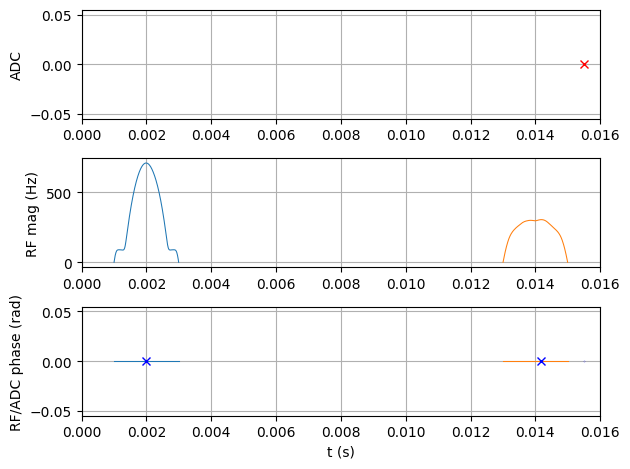

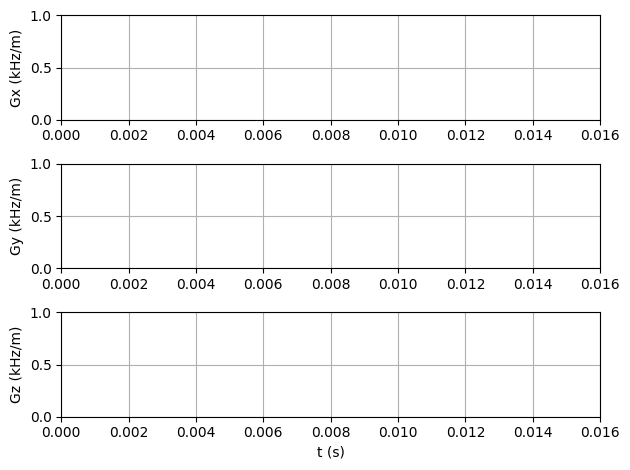

In [8]:
# Timing-Check und Sequenz plotten
if FLAG_CHECK_TIMING:
    ok, error_report = seq.check_timing()
    if ok:
        print("\nTiming check passed successfully")
    else:
        print("\nTiming check failed! Error listing follows\n")
        print(error_report)

if FLAG_PLOT_SEQUENCE:
    seq.plot() # Ggf. time_range anpassen, um Details zu sehen

In [9]:
# Sequenzdatei schreiben
write_seq(seq=seq, seq_defs=defs, filename=folder / seq_filename, author=AUTHOR, use_matlab_names=True)
print(f"Optimierte SE-Sequenz wurde unter {folder / seq_filename} gespeichert")

Optimierte SE-Sequenz wurde unter /Users/danielmiksch/JupyterLab/optim/seq_lib/SE_opt_163_8.seq gespeichert


## Vergleich: Optimierte vs. Original-SE-Sequenz

Zum Abschluss können Informationen aus der Optimierung angezeigt werden.

In [10]:
# Informationen aus Checkpoint und Metadaten anzeigen
print("\n--- Optimierungs-Ergebnisse ---")
signal_value = checkpoint.get('signal', None)
loss_value = checkpoint.get('loss', None)

if signal_value is not None:
     print(f"Bestes Signal laut Optimierung: {signal_value:.6f}")
if loss_value is not None:
     print(f"Verlust beim besten Signal: {loss_value:.6f}")

# Versuche, das ursprüngliche Signal aus dem Training zu laden (falls gespeichert)
# Hinweis: Dies erfordert, dass das ursprüngliche Signal im Checkpoint gespeichert wurde.
# Die aktuelle `save_checkpoint`-Funktion in SE_optimization.ipynb speichert dies nicht standardmäßig.
# original_signal_from_training = checkpoint.get('original_signal', None)
# if original_signal_from_training is not None and signal_value is not None:
#     try:
#         improvement = (signal_value - original_signal_from_training) / abs(original_signal_from_training) * 100
#         print(f"Ursprüngliches Signal (Training): {original_signal_from_training:.6f}")
#         print(f"Verbesserung durch Optimierung: {improvement:.2f}%")
#     except ZeroDivisionError:
#         print("Ursprüngliches Signal war 0, Verbesserung nicht berechenbar.")
# else:
#     print("Ursprüngliches Signal nicht im Checkpoint gefunden für Vergleich.")


--- Optimierungs-Ergebnisse ---
Bestes Signal laut Optimierung: 0.682456
Verlust beim besten Signal: -0.538804


## Zusammenfassung

In diesem Notebook haben wir:
1. Die optimierten 90°- und 180°-Pulse aus dem gespeicherten Checkpoint der SE-Optimierung geladen.
2. Die Pulse visualisiert und als NumPy-Arrays exportiert.
3. Eine Spin-Echo-Sequenzdatei mit den optimierten Pulsen unter Verwendung von `make_arbitrary_rf` erstellt.
4. Die Sequenz als Pulseq-Datei (.seq) gespeichert.

Die optimierte SE-Sequenzdatei (`SE_opt.seq`) kann nun für weitere Simulationen oder Experimente verwendet werden.